In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mattiuzc/stock-exchange-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stock-exchange-data' dataset.
Path to dataset files: /kaggle/input/stock-exchange-data


In [ ]:
df=pd.read_csv("/kaggle/input/stock-exchange-data/indexData.csv")

In [ ]:
df.head()

,Index,Date,Open,High,Low,Close,Adj Close,Volume
0,NYA,1965-12-31,528.690002,528.690002,528.690002,528.690002,528.690002,0.0
1,NYA,1966-01-03,527.210022,527.210022,527.210022,527.210022,527.210022,0.0
2,NYA,1966-01-04,527.840027,527.840027,527.840027,527.840027,527.840027,0.0
3,NYA,1966-01-05,531.119995,531.119995,531.119995,531.119995,531.119995,0.0
4,NYA,1966-01-06,532.070007,532.070007,532.070007,532.070007,532.070007,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112457 entries, 0 to 112456
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Index      112457 non-null  object 
 1   Date       112457 non-null  object 
 2   Open       110253 non-null  float64
 3   High       110253 non-null  float64
 4   Low        110253 non-null  float64
 5   Close      110253 non-null  float64
 6   Adj Close  110253 non-null  float64
 7   Volume     110253 non-null  float64
dtypes: float64(6), object(2)
memory usage: 6.9+ MB


In [ ]:
df.shape

(112457, 8)

In [ ]:
df=df.drop(columns=['Adj Close'])
df=df.drop('Index',axis=1)

In [ ]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [ ]:
df.isna().sum()

,0
Date,0
Open,2204
High,2204
Low,2204
Close,2204
Volume,2204


In [ ]:
df.duplicated().sum()

np.int64(789)

In [ ]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [ ]:
df['Date']=pd.to_datetime(df['Date'])
df.set_index('Date',inplace=True)

In [ ]:
df=df.sort_index()

In [ ]:
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
1965-01-05,1257.719971,1257.719971,1257.719971,1257.719971,0.0
1965-01-06,1263.989990,1263.989990,1263.989990,1263.989990,0.0
1965-01-07,1274.270020,1274.270020,1274.270020,1274.270020,0.0
1965-01-08,1286.430054,1286.430054,1286.430054,1286.430054,0.0
1965-01-12,1288.540039,1288.540039,1288.540039,1288.540039,0.0


In [ ]:
df.describe()

,Open,High,Low,Close,Volume
count,110253.000000,110253.000000,110253.000000,110253.000000,1.102530e+05
mean,7658.515222,7704.372961,7608.000422,7657.545872,1.273975e+09
std,9011.478913,9066.638548,8954.506981,9011.510444,4.315783e+09
min,54.869999,54.869999,54.869999,54.869999,0.000000e+00
25%,1855.030029,1864.510010,1843.979980,1855.060059,0.000000e+00
50%,5194.089844,5226.279785,5154.049805,5194.750000,4.329000e+05
75%,10134.299810,10207.820310,10060.349610,10134.830080,1.734314e+08
max,68775.062500,69403.750000,68516.992190,68775.062500,9.440374e+10


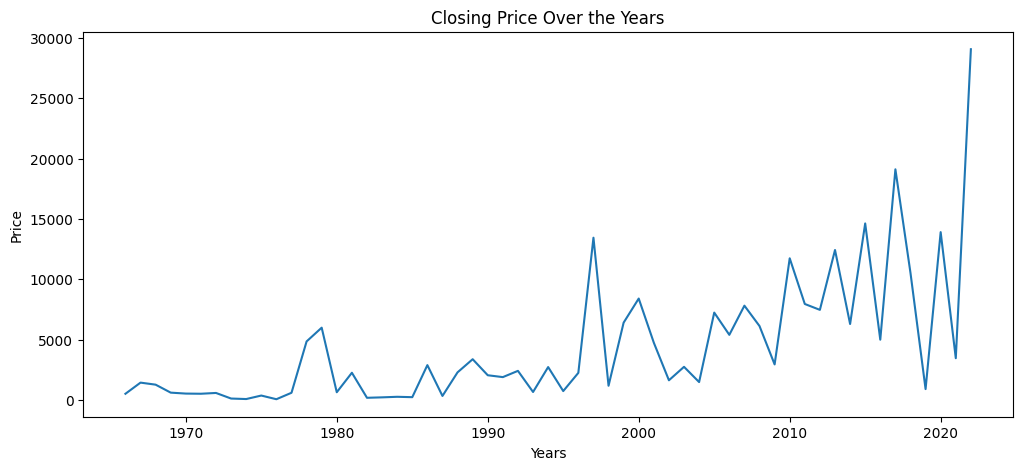

In [ ]:
df_yearly = df['Close'].resample('YE').last()

plt.figure(figsize=(12, 5))
plt.plot(df_yearly.index, df_yearly)
plt.title('Closing Price Over the Years')
plt.xlabel('Years')
plt.ylabel('Price')

plt.show()

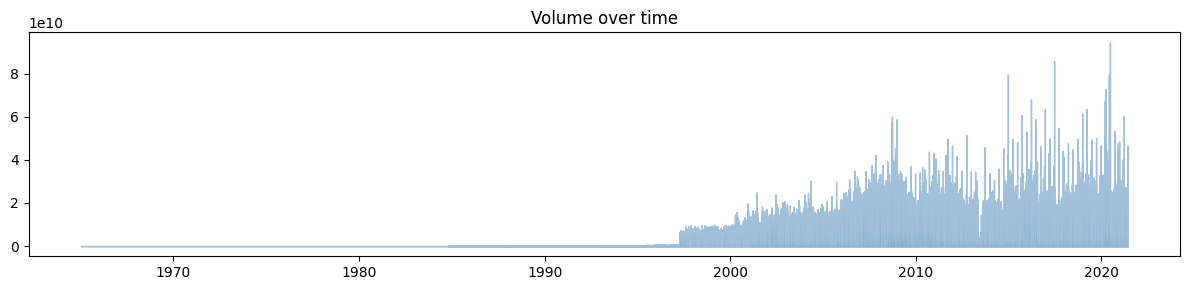

In [ ]:
plt.figure(figsize=(12, 3))
plt.fill_between(df.index, df['Volume'], alpha=0.5, color='steelblue')
plt.title('Volume over time')
plt.tight_layout()
plt.show()

### **Feature Engineering & EDA**

In [ ]:
# Latest Closing Price
df['Target']=df['Close'].shift(-1)

In [ ]:
# Closing Price the day before
df['yesterday_close']=df['Close'].shift(1)

In [ ]:
#Open/Close & High/low diff prices
df['close-open'] = df['Close'] - df['Open']
df['high-low']= df['High'] - df['Low']

In [ ]:
#Moving Averages for n days
for w in [5,10,20]:
    df[f"MA_{w}"]=df['Close'].rolling(w).mean()

In [ ]:
df['volume_ratio']=df['Volume']/df['Volume'].rolling(20).mean()

In [ ]:
df['HL_range']=(df['High']-df['Low'])/df['Close']

In [ ]:
# Daily Return - todays close price - yesterday close price / yesterday close price
# df['daily_return']= (df['Close']-df['yesterday_close'])/df['yesterday_close']
df['daily_return'] = df['Close'].pct_change()

In [ ]:
delta = df['Close'].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

df['rsi'] = 100 - (100 / (1 + rs))

In [ ]:
df.isna().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0
Target,1
yesterday_close,1
close-open,0
high-low,0
MA_5,4


In [ ]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Target', 'yesterday_close',
       'close-open', 'high-low', 'MA_5', 'MA_10', 'MA_20', 'volume_ratio',
       'HL_range', 'daily_return', 'rsi'],
      dtype='object')

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.head()

,Open,High,Low,Close,Volume,Target,yesterday_close,close-open,high-low,MA_5,MA_10,MA_20,volume_ratio,HL_range,daily_return,rsi
Date,,,,,,,,,,,,,,,,
1984-10-11,244.199997,244.699997,244.199997,244.699997,62860000.0,2365.899902,989.380005,0.500000,0.500000,964.613977,1932.691983,2979.380502,20.000000,0.002043,-0.752673,48.429669
1984-10-11,2362.899902,2368.500000,2360.399902,2365.899902,0.0,993.609985,244.699997,3.000000,8.100098,1240.233960,2070.332974,3048.116498,0.000000,0.003424,8.668573,51.005215
1984-10-11,993.609985,993.609985,993.609985,993.609985,0.0,10696.860350,2365.899902,0.000000,0.000000,1390.297958,2145.237973,3048.126996,0.000000,0.000000,-0.580029,41.870238
1984-10-11,10696.860350,10696.860350,10696.860350,10696.860350,0.0,246.199997,993.609985,0.000000,0.000000,3058.090048,3190.515008,3464.480011,0.000000,0.000000,9.765653,58.836316
1984-10-12,245.500000,246.199997,245.500000,246.199997,58860000.0,1002.280029,10696.860350,0.699997,0.699997,2909.454046,2148.264012,3464.530011,9.671377,0.002843,-0.976984,41.184021


In [ ]:
print(df['rsi'].describe())

count    95896.000000
mean        50.002054
std          4.971677
min         17.021566
25%         47.749104
50%         50.000930
75%         52.260849
max         85.193697
Name: rsi, dtype: float64


In [ ]:
#Neutral
((df['rsi']>30) & (df['rsi']<70)).sum()

np.int64(95709)

In [ ]:
#Overbought
(df['rsi'] > 70).sum()

np.int64(89)

In [ ]:
#oversold
(df['rsi'] < 30).sum()

np.int64(98)

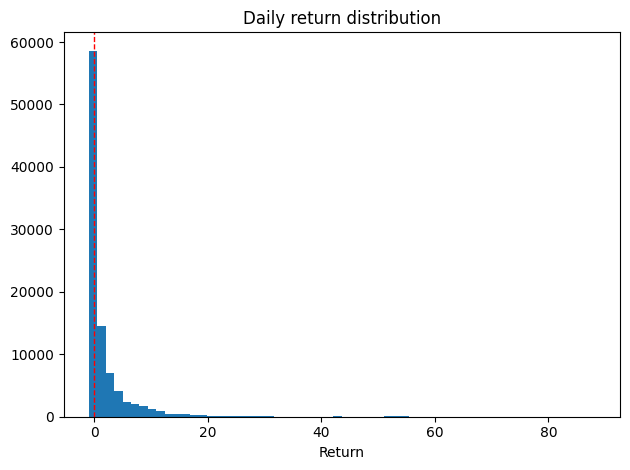

In [ ]:
plt.hist(df['daily_return'], bins=60)
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.title('Daily return distribution')
plt.xlabel('Return')
plt.tight_layout()
plt.show()

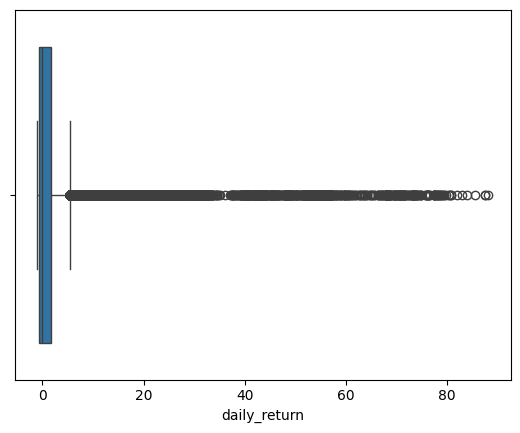

In [ ]:
sns.boxplot(x=df['daily_return'])
plt.show()

In [ ]:
df['daily_return'].describe()

,daily_return
count,95896.000000
mean,1.853678
std,5.941309
min,-0.988771
25%,-0.637762
50%,-0.000462
75%,1.774695
max,88.176095


The daily returns are positively skewed, meaning most daily changes are small, but there are a few unusually large positive returns that pull the distribution to the right

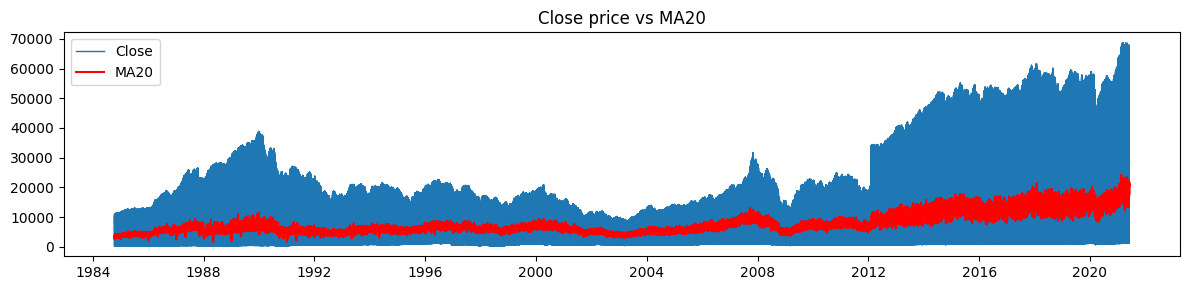

In [ ]:
plt.figure(figsize=(12, 3))
plt.plot(df.index, df['Close'], linewidth=1, label='Close')
plt.plot(df.index, df['MA_20'], linewidth=1.5, color='red', label='MA20')
plt.title('Close price vs MA20')
plt.legend()
plt.tight_layout()
plt.show()

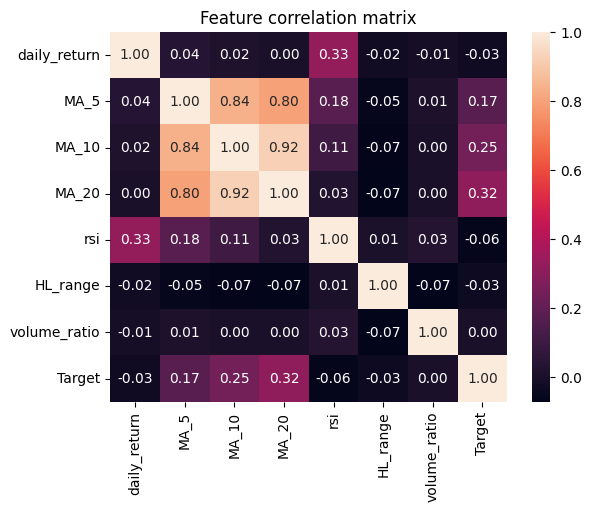

In [ ]:
engineerd_col = ['daily_return', 'MA_5','MA_10', 'MA_20', 'rsi', 'HL_range', 'volume_ratio', 'Target']

sns.heatmap(df[engineerd_col].corr(), annot=True, fmt='.2f')
plt.title('Feature correlation matrix')
plt.show()

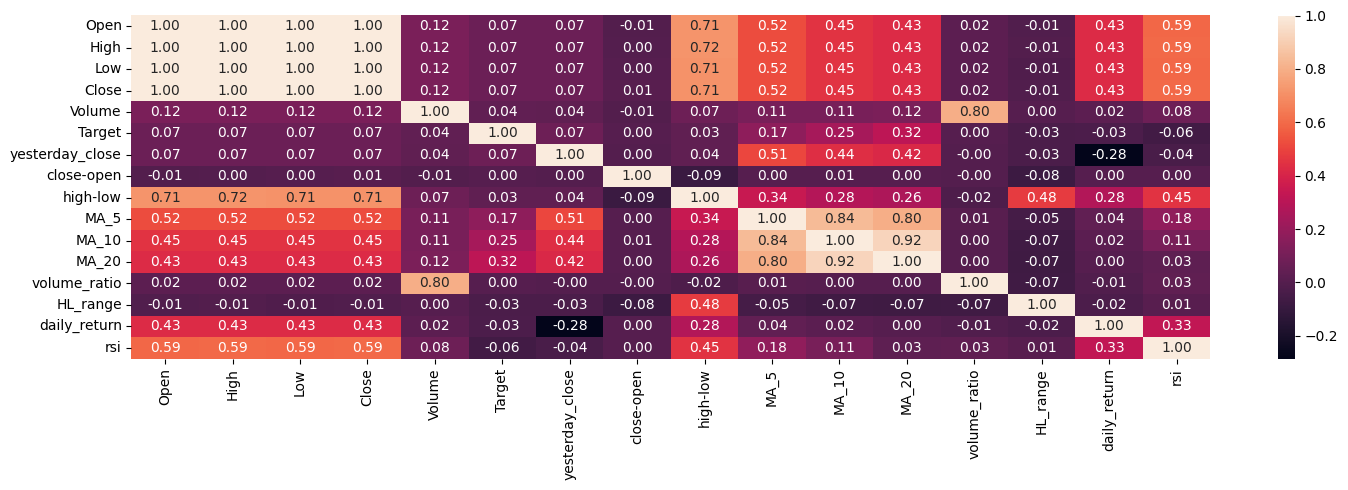

In [ ]:
plt.figure(figsize=(15,5))
sns.heatmap(df.corr(),annot=True,fmt='.2f')
plt.tight_layout()
plt.show()

In [ ]:
df['Target_class'] = (df['Close'].shift(-1) > df['Close']).astype(int)
print(df['Target_class'].value_counts())

Target_class
0    47979
1    47917
Name: count, dtype: int64


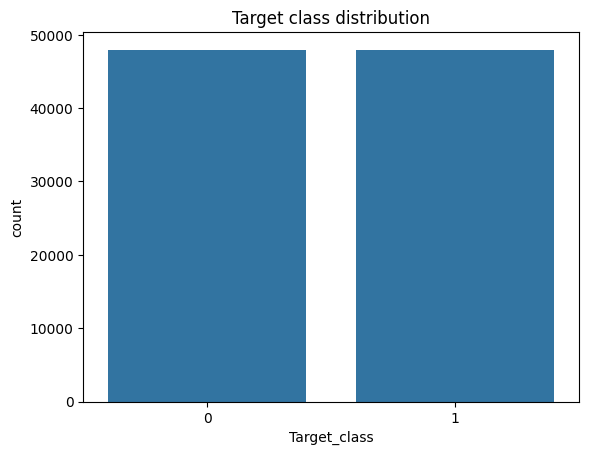

In [ ]:
sns.countplot(x=df['Target_class'])
plt.title('Target class distribution')
plt.show()

In [ ]:
Predictors = ['daily_return', 'MA_20', 'rsi', 'HL_range', 'volume_ratio','close-open','high-low']

In [ ]:
X=df[Predictors].values
y=df['Target_class'].values

In [ ]:
train_size = int (len(df)*0.8)
X_train, X_test, y_train, y_test = X[:train_size], X[train_size:], y[:train_size], y[train_size:]

In [ ]:
print(f"Shape of X_train: {X_train.shape[0]}")
print(f"Shape of X_test: {X_test.shape[0]}")

Shape of X_train: 76716
Shape of X_test: 19180


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **Models (Training Phase)**

In [ ]:
Random_Forest = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
Random_Forest.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred_rf=Random_Forest.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=['Don\'t Buy (0)', 'BUY (1)']))

               precision    recall  f1-score   support

Don't Buy (0)       0.66      0.86      0.75      9607
      BUY (1)       0.81      0.56      0.66      9573

     accuracy                           0.71     19180
    macro avg       0.73      0.71      0.71     19180
 weighted avg       0.73      0.71      0.71     19180



In [ ]:
Logisitic_Regression=LogisticRegression(max_iter=1000)
Logisitic_Regression.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr=Logisitic_Regression.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr, target_names=['Don\'t Buy (0)', 'BUY (1)']))

               precision    recall  f1-score   support

Don't Buy (0)       0.70      0.75      0.73      9607
      BUY (1)       0.73      0.68      0.71      9573

     accuracy                           0.72     19180
    macro avg       0.72      0.72      0.72     19180
 weighted avg       0.72      0.72      0.72     19180



In [ ]:
Knn=KNeighborsClassifier(n_neighbors=5)
Knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
y_pred_knn=Knn.predict(X_test_scaled)
print(classification_report(y_test, y_pred_knn, target_names=['Don\'t Buy (0)', 'BUY (1)']))

               precision    recall  f1-score   support

Don't Buy (0)       0.69      0.78      0.73      9607
      BUY (1)       0.74      0.65      0.69      9573

     accuracy                           0.71     19180
    macro avg       0.71      0.71      0.71     19180
 weighted avg       0.71      0.71      0.71     19180



In [ ]:
svm=SVC()
svm.fit(X_train_scaled, y_train)

SVC()

In [ ]:
y_pred_svm=svm.predict(X_test_scaled)
print(classification_report(y_test, y_pred_svm, target_names=['Don\'t Buy (0)', 'BUY (1)']))

               precision    recall  f1-score   support

Don't Buy (0)       0.67      0.89      0.76      9607
      BUY (1)       0.83      0.55      0.66      9573

     accuracy                           0.72     19180
    macro avg       0.75      0.72      0.71     19180
 weighted avg       0.75      0.72      0.71     19180



In [ ]:
Naive_Bayes=GaussianNB()
Naive_Bayes.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred_nb=Naive_Bayes.predict(X_test)
print(classification_report(y_test, y_pred_nb, target_names=['Don\'t Buy (0)', 'BUY (1)']))

               precision    recall  f1-score   support

Don't Buy (0)       0.75      0.59      0.66      9607
      BUY (1)       0.66      0.80      0.72      9573

     accuracy                           0.69     19180
    macro avg       0.70      0.69      0.69     19180
 weighted avg       0.70      0.69      0.69     19180



### **Neural Networks**

In [ ]:
X_train.shape[1]

7

In [ ]:
nn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

In [ ]:
nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
history=nn.fit(X_train_scaled, y_train, epochs=25, batch_size=32, validation_split=0.2, shuffle=False, callbacks=[early_stop])

Epoch 1/25
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7529 - loss: 0.4844 - val_accuracy: 0.6548 - val_loss: 0.6889
Epoch 2/25
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7534 - loss: 0.4809 - val_accuracy: 0.6751 - val_loss: 0.6308
Epoch 3/25
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7560 - loss: 0.4784 - val_accuracy: 0.6838 - val_loss: 0.6448
Epoch 4/25
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7568 - loss: 0.4780 - val_accuracy: 0.6827 - val_loss: 0.6333
Epoch 5/25
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7581 - loss: 0.4768 - val_accuracy: 0.6928 - val_loss: 0.6115
Epoch 6/25
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7587 - loss: 0.4753 - val_accuracy: 0.6908 - val_loss: 0.6329
Epoch 7/25
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7591 - loss: 0.4751 - val_accuracy: 0.7042 - val_loss: 0.6105
Epoch 8/25
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7597 - loss: 0.4754 

In [ ]:
loss, accuracy = nn.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {accuracy:.2%}")

600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6123 - loss: 0.9034
Test Accuracy: 61.23%


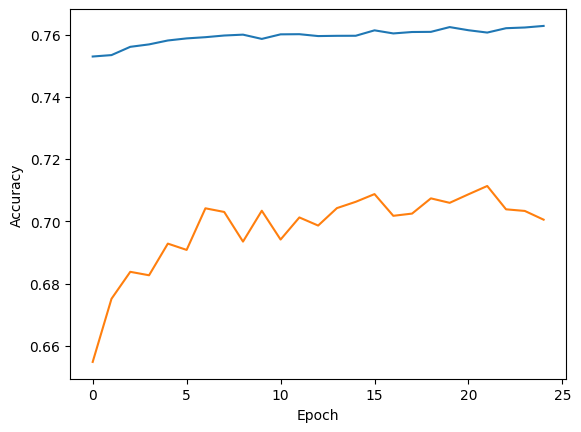

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
predictions = nn.predict(X_test_scaled)

predicted_classes = (predictions > 0.5).astype(int)
print(f"Actual: {y_test[:5]}")
print(f"Predicted: {predicted_classes[:5].tolist()}")

600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Actual: [1 0 0 1 0]
Predicted: [[0], [0], [0], [1], [0]]


**LSTM**

In [ ]:
lstm_model = Sequential([

    LSTM(units=50, return_sequences=True,input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),

    LSTM(units=50, return_sequences=True),
    Dropout(0.2),

    LSTM(units=50),
    Dropout(0.2),

    Dense(units=1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lstm_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
lstm_history=lstm_model.fit(X_train_scaled, y_train, epochs=25, batch_size=32, validation_split=0.2, shuffle=False, callbacks=[early_stop])

Epoch 1/25
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 72s 32ms/step - accuracy: 0.7021 - loss: 0.5661 - val_accuracy: 0.5703 - val_loss: 0.7760
Epoch 2/25
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 66s 34ms/step - accuracy: 0.7076 - loss: 0.5514 - val_accuracy: 0.5832 - val_loss: 0.8664
Epoch 3/25
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.7281 - loss: 0.5173 - val_accuracy: 0.5980 - val_loss: 0.9291
Epoch 4/25
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.7347 - loss: 0.5075 - val_accuracy: 0.5915 - val_loss: 0.8766
Epoch 5/25
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.7423 - loss: 0.4987 - val_accuracy: 0.6114 - val_loss: 0.7638
Epoch 6/25
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.7493 - loss: 0.4897 - val_accuracy: 0.6254 - val_loss: 0.7353
Epoch 7/25
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 49s 21ms/step - accuracy: 0.7527 - loss: 0.4836 - val_accuracy: 0.6328 - val_loss: 0.7165
Epoch 8/25
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.7540 -

In [ ]:
loss, accuracy = lstm_model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {accuracy:.2%}")

600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5294 - loss: 0.9253
Test Accuracy: 52.94%
